#Computer Vision HW №2
## Выполнила Чернавцева Алина


In [1]:
import torch
import triton
import triton.language as tl

In [2]:
def layernorm_forward_torch(x, weight, bias, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var  = x.var(dim=-1, unbiased=False, keepdim=True)
    rstd = 1.0 / torch.sqrt(var + eps)
    return (x - mean) * rstd * weight + bias

In [3]:
@triton.autotune(
    configs=[
        triton.Config({"BLOCK_N": bn}, num_warps=nw)
        for bn in [64, 128, 256, 512, 1024, 2048]
        for nw in [2, 4, 8]
    ],
    key=["N"],
)
@triton.jit
def _layernorm_fwd_kernel(
    X_ptr, W_ptr, B_ptr,
    Y_ptr, Mean_ptr, Rstd_ptr,
    M, N,
    eps: tl.constexpr,
    BLOCK_N: tl.constexpr,
):
    row   = tl.program_id(0)
    X_row = X_ptr + row * N
    Y_row = Y_ptr + row * N

    mean = 0.0
    for off in tl.range(0, N, BLOCK_N):
        cols = off + tl.arange(0, BLOCK_N)
        x = tl.load(X_row + cols, mask=cols < N, other=0.0).to(tl.float32)
        mean += tl.sum(x, axis=0)
    mean = mean / N

    var = 0.0
    for off in tl.range(0, N, BLOCK_N):
        cols = off + tl.arange(0, BLOCK_N)
        mask = cols < N
        x    = tl.load(X_row + cols, mask=mask, other=mean).to(tl.float32)
        d    = x - mean
        var += tl.sum(d * d, axis=0)
    var  = var / N
    rstd = 1.0 / tl.sqrt(var + eps)

    tl.store(Mean_ptr + row, mean)
    tl.store(Rstd_ptr + row, rstd)

    for off in tl.range(0, N, BLOCK_N):
        cols = off + tl.arange(0, BLOCK_N)
        mask = cols < N
        x = tl.load(X_row + cols, mask=mask, other=0.0).to(tl.float32)
        w = tl.load(W_ptr  + cols, mask=mask, other=0.0).to(tl.float32)
        b = tl.load(B_ptr  + cols, mask=mask, other=0.0).to(tl.float32)
        y = (x - mean) * rstd * w + b
        tl.store(Y_row + cols, y, mask=mask)

In [4]:
@triton.autotune(
    configs=[
        triton.Config({"BLOCK_N": bn}, num_warps=nw)
        for bn in [64, 128, 256, 512, 1024, 2048]
        for nw in [2, 4, 8]
    ],
    key=["N"],
)
@triton.jit
def _layernorm_bwd_kernel(
    DY_ptr, X_ptr, W_ptr,
    Mean_ptr, Rstd_ptr,
    DX_ptr, DW_ptr, DB_ptr,
    M, N,
    BLOCK_N: tl.constexpr,
):
    row    = tl.program_id(0)
    DY_row = DY_ptr + row * N
    X_row  = X_ptr  + row * N
    DX_row = DX_ptr + row * N

    mean = tl.load(Mean_ptr + row).to(tl.float32)
    rstd = tl.load(Rstd_ptr + row).to(tl.float32)

    dot1 = 0.0
    dot2 = 0.0
    for off in tl.range(0, N, BLOCK_N):
        cols  = off + tl.arange(0, BLOCK_N)
        mask  = cols < N
        dy    = tl.load(DY_row + cols, mask=mask, other=0.0).to(tl.float32)
        x     = tl.load(X_row  + cols, mask=mask, other=0.0).to(tl.float32)
        w     = tl.load(W_ptr  + cols, mask=mask, other=0.0).to(tl.float32)
        x_hat = (x - mean) * rstd
        dyw   = dy * w
        dot1 += tl.sum(dyw * x_hat, axis=0)
        dot2 += tl.sum(dyw, axis=0)

    for off in tl.range(0, N, BLOCK_N):
        cols  = off + tl.arange(0, BLOCK_N)
        mask  = cols < N
        dy    = tl.load(DY_row + cols, mask=mask, other=0.0).to(tl.float32)
        x     = tl.load(X_row  + cols, mask=mask, other=0.0).to(tl.float32)
        w     = tl.load(W_ptr  + cols, mask=mask, other=0.0).to(tl.float32)
        x_hat = (x - mean) * rstd
        dyw   = dy * w
        dx    = rstd / N * (N * dyw - dot2 - x_hat * dot1)
        tl.store(DX_row + cols, dx, mask=mask)
        tl.atomic_add(DW_ptr + cols, dy * x_hat, mask=mask)
        tl.atomic_add(DB_ptr + cols, dy,          mask=mask)

In [5]:
class _LayerNormTriton(torch.autograd.Function):

    @staticmethod
    def forward(ctx, x, weight, bias, eps):
        x      = x.contiguous()
        weight = weight.contiguous()
        bias   = bias.contiguous()

        shape = x.shape
        x2d   = x.view(-1, shape[-1])
        M, N  = x2d.shape

        y    = torch.empty_like(x2d)
        mean = torch.empty(M, dtype=torch.float32, device=x.device)
        rstd = torch.empty(M, dtype=torch.float32, device=x.device)

        _layernorm_fwd_kernel[(M,)](x2d, weight, bias, y, mean, rstd, M, N, eps)

        ctx.save_for_backward(x2d, weight, mean, rstd)
        ctx.eps = eps
        return y.view(shape)

    @staticmethod
    def backward(ctx, dy):
        x2d, weight, mean, rstd = ctx.saved_tensors
        dy   = dy.contiguous().view(x2d.shape)
        M, N = x2d.shape

        dx = torch.empty_like(x2d)
        dw = torch.zeros(N, dtype=torch.float32, device=x2d.device)
        db = torch.zeros(N, dtype=torch.float32, device=x2d.device)

        _layernorm_bwd_kernel[(M,)](
            dy, x2d, weight, mean, rstd, dx, dw, db, M, N
        )
        return dx.view_as(x2d), dw.to(weight.dtype), db.to(weight.dtype), None


def layernorm_triton(x, weight, bias, eps=1e-5):
    return _LayerNormTriton.apply(x, weight, bias, eps)

In [6]:
def check_correctness():
    print("=" * 60)
    print("Проверка корректности")
    print("=" * 60)
    torch.manual_seed(0)
    device = "cuda"

    for M, N in [(4, 128), (16, 512), (128, 1024), (256, 4096)]:
        x_ref = torch.randn(M, N, device=device, requires_grad=True)
        x_tri = x_ref.detach().clone().requires_grad_(True)
        w = torch.randn(N, device=device)
        b = torch.randn(N, device=device)

        y_ref = layernorm_forward_torch(x_ref, w, b)
        y_tri = layernorm_triton(x_tri, w.clone(), b.clone())

        torch.testing.assert_close(y_tri, y_ref, rtol=1e-3, atol=1e-3)
        print(f"  [{M:4d}×{N:4d}]  forward  +")

        dy = torch.randn_like(y_ref)
        y_ref.backward(dy)
        y_tri.backward(dy)

        torch.testing.assert_close(x_tri.grad, x_ref.grad, rtol=1e-3, atol=1e-3)
        print(f"  [{M:4d}×{N:4d}]  backward +")

    print("\nВсе проверки пройдены\n")

In [7]:
def text_benchmark():
    print("=" * 60)
    print("Бенчмарк (forward), M=4096")
    print("=" * 60)
    device = "cuda"
    dtype  = torch.float16
    M      = 4096

    print(f"{'N':>6}  {'PyTorch GB/s':>13}  {'Triton GB/s':>12}  {'Speedup':>8}")
    print("-" * 48)
    for N in [128, 256, 512, 1024, 2048, 4096, 8192]:
        x = torch.randn(M, N, device=device, dtype=dtype)
        w = torch.ones (N,    device=device, dtype=dtype)
        b = torch.zeros(N,    device=device, dtype=dtype)

        nbytes = (x.numel() * 2 + w.numel() + b.numel()) * dtype.itemsize

        ms_torch  = triton.testing.do_bench(lambda: layernorm_forward_torch(x, w, b))
        ms_triton = triton.testing.do_bench(lambda: layernorm_triton(x, w, b))

        gbps_t = nbytes * 1e-9 / (ms_torch  * 1e-3)
        gbps_r = nbytes * 1e-9 / (ms_triton * 1e-3)
        print(f"{N:>6}  {gbps_t:>13.1f}  {gbps_r:>12.1f}  {gbps_r/gbps_t:>7.2f}x")
    print()

In [8]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=[128, 256, 512, 1024, 2048, 4096, 8192],
        line_arg="provider",
        line_vals=["torch", "triton"],
        line_names=["PyTorch", "Triton"],
        styles=[("blue", "-"), ("red", "-")],
        ylabel="GB/s",
        plot_name="LayerNorm-Forward",
        args={"M": 4096},
    )
)
def bench_fwd(M, N, provider):
    dtype = torch.float16
    x = torch.randn(M, N, device="cuda", dtype=dtype)
    w = torch.ones (N,    device="cuda", dtype=dtype)
    b = torch.zeros(N,    device="cuda", dtype=dtype)
    fn = (lambda: layernorm_forward_torch(x, w, b)) if provider == "torch" \
         else (lambda: layernorm_triton(x, w, b))
    ms, lo, hi = triton.testing.do_bench(fn, quantiles=[0.5, 0.2, 0.8])
    nb = (x.numel() * 2 + w.numel() + b.numel()) * dtype.itemsize
    return nb*1e-9/(ms*1e-3), nb*1e-9/(hi*1e-3), nb*1e-9/(lo*1e-3)


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=[128, 256, 512, 1024, 2048, 4096, 8192],
        line_arg="provider",
        line_vals=["torch", "triton"],
        line_names=["PyTorch", "Triton"],
        styles=[("blue", "-"), ("red", "-")],
        ylabel="GB/s",
        plot_name="LayerNorm-Backward",
        args={"M": 4096},
    )
)
def bench_bwd(M, N, provider):
    dtype = torch.float16
    x = torch.randn(M, N, device="cuda", dtype=dtype, requires_grad=True)
    w = torch.ones (N,    device="cuda", dtype=dtype, requires_grad=True)
    b = torch.zeros(N,    device="cuda", dtype=dtype, requires_grad=True)
    y = layernorm_forward_torch(x, w, b) if provider == "torch" \
        else layernorm_triton(x, w, b)
    dy = torch.randn_like(y)
    fn = lambda: y.backward(dy, retain_graph=True)
    ms, lo, hi = triton.testing.do_bench(fn, quantiles=[0.5, 0.2, 0.8])
    nb = 4 * x.numel() * dtype.itemsize
    return nb*1e-9/(ms*1e-3), nb*1e-9/(hi*1e-3), nb*1e-9/(lo*1e-3)

Проверка корректности
  [   4× 128]  forward  +
  [   4× 128]  backward +
  [  16× 512]  forward  +
  [  16× 512]  backward +
  [ 128×1024]  forward  +
  [ 128×1024]  backward +
  [ 256×4096]  forward  +
  [ 256×4096]  backward +

Все проверки пройдены

Бенчмарк (forward), M=4096
     N   PyTorch GB/s   Triton GB/s   Speedup
------------------------------------------------
   128           32.3         122.0     3.78x
   256           40.2         184.9     4.59x
   512           35.0         215.0     6.13x
  1024           37.5         228.3     6.08x
  2048           38.9         236.8     6.08x
  4096           37.3         240.0     6.43x
  8192           34.7         161.7     4.66x

Генерируем графики…
LayerNorm-Forward:
        N  PyTorch (GB/s)  Triton (GB/s)
0   128.0       28.954063     113.215892
1   256.0       38.650944     185.963117
2   512.0       34.872721     214.836546
3  1024.0       37.080856     228.603312
4  2048.0       38.229011     237.668715
5  4096.0       

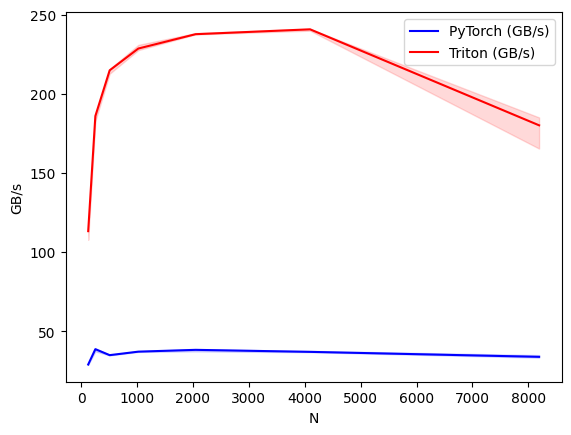

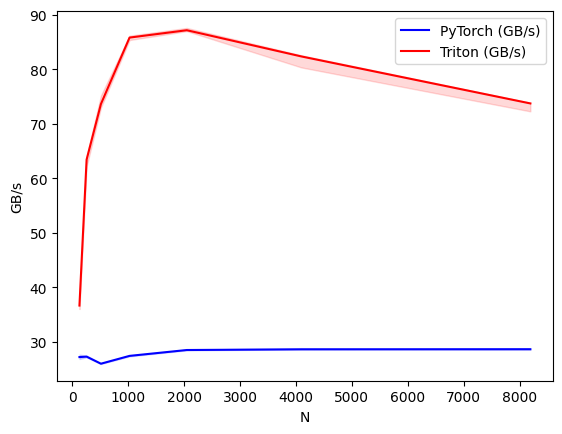

In [9]:
if __name__ == "__main__":
    assert torch.cuda.is_available(), "Нужна CUDA GPU"

    check_correctness()
    text_benchmark()

    print("Генерируем графики…")
    bench_fwd.run(show_plots=False, print_data=True, save_path=".")
    bench_bwd.run(show_plots=False, print_data=True, save_path=".")
    print("Графики сохранены: LayerNorm-Forward.png, LayerNorm-Backward.png")


**Вывод:** Triton-реализация LayerNorm превосходит PyTorch по пропускной способности в 4-6 раз на forward pass и в 2.5-3 раз на backward pass; выигрыш объясняется фьюзингом всех операций в один kernel и отсутствием промежуточных записей в глобальную память.